# Vulgar Modification Handling with an NSFW Classifier

This notebook uses a pretrained Hugging Face image-classification model to estimate whether an image is NSFW. If the image is flagged above a threshold, the example optionally saves a **fully blurred copy**.

**Important:** a classifier generally scores the whole image; it does not identify the exact region to blur. This starter is for experimentation and must be evaluated before production use.

## 1. Install dependencies



In [ ]:
%pip install transformers torch pillow

## 2. Import the function



In [5]:
from vulgar_modification_nsfw import handle_nsfw_image
import json

## 3. Select an image and run classification



In [4]:
image_path = 'download.jpeg'  # Change this path
result = handle_nsfw_image(
    image_path=image_path,
    output_dir='outputs',
    threshold=0.60,
    blur_if_nsfw=True,


)
print(json.dumps(result, indent=2))

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 331.04it/s]


{
  "input_image": "download.jpeg",
  "model_name": "Falconsai/nsfw_image_detection",
  "is_nsfw": true,
  "nsfw_score": 0.9966,
  "threshold": 0.6,
  "predictions": [
    {
      "label": "nsfw",
      "confidence": 0.9966
    },
    {
      "label": "normal",
      "confidence": 0.0034
    }
  ],
  "blurred_image": "outputs\\download_nsfw_blurred.jpg",
  "note": "The classifier scores the whole image; the blur covers the whole image. This is not a localized body-region detector."
}


## 4. Display the blurred output, if one was created


In [ ]:
from IPython.display import display, Image

if result['blurred_image']:
    display(Image(filename=result['blurred_image']))
else:
    print('No blurred output was created. The image was not flagged above the threshold.')

## 5. Understand the output

- `is_nsfw`: whether the NSFW score reached the threshold.
- `nsfw_score`: score associated with the model's NSFW-like label.
- `predictions`: labels and confidence scores returned by the classifier.
- `blurred_image`: path of the fully blurred copy, or `None` if not created.

A model can miss explicit content or flag non-explicit content. Check the model card and label mapping for the selected checkpoint, then test precision and recall on a suitable validation set.

## Pipeline summary

Input image → pretrained NSFW classifier → compare score with threshold → optionally blur the entire image → return prediction metadata.

If your app must blur only explicit regions, use a detector that returns bounding boxes or a segmentation model. A whole-image classifier alone cannot tell this code which pixels to blur.

### ⚠️ NSFW Image Detected — Blurred Output

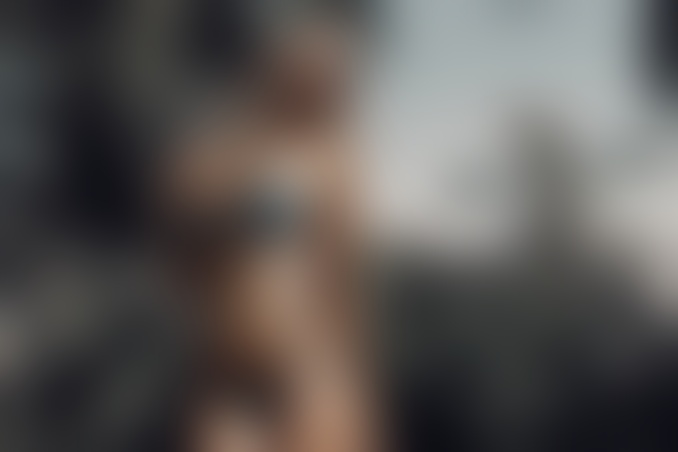

In [6]:
from PIL import Image
from IPython.display import display, Markdown

if result["is_nsfw"] and result["blurred_image"]:
    display(Markdown("### ⚠️ NSFW Image Detected — Blurred Output"))

    blurred_image = Image.open(result["blurred_image"])
    display(blurred_image)

else:
    display(Markdown("### ✅ Image classified as Normal"))